### SUPPORT VECTOR CLASSIFIER MODELING

The following **SVC models** are prepared:

_Model S1_     
A simple model is first built.

_Model S2_   
The class imbalance is addressed using the parameter _class\_weight_. The model is also optimized.

_Model S3_    
The best threshold is used.

_Model S4_    
Feature selection is applied using SelectKBest.

_Model S5_    
Feature selection is applied using Random Forest Classifier.

The following **metrics** are determined:    
_AUC_       
_Accuracy_    
_Precision_       
_Recall_    
_F2 Score_    
_Profit/Loss_    

The best model is chosen based on business goals that consider the relative cost of missing a churner (_false negatives_ - predicted not to churn but churned, loss of lifetime value), cost of false alarms (_false positives_ - predicted to churn but stayed, cost of retention offer) and _true positives_ (predicted to stay and actually stayed, saved lifetime value less the cost of retention offer).

In customer churn, missing churners (_recall_) is more expensive than false alarms (_precision_).  Recall is, therefore, optimized at the expense of precision and accuracy.

**Hyperparameters Tuning**    
Model hyperparameters are optimized using grid search to maximize model performance particularly addressing overfitting.  

**Feature Importance**     
The features and their importances are examined to verify the magnitude of features influence on customer churn.   

**Feature Selection**    
Feature selection reduces the number of features to improve the model and to lessen noise. When there is less noise, the interpretability of feature importance improves. Noise in this context is irrelevant information that obscures underlying patterns or relationships the model is trying to learn.  

**Sample Predictions**     
Sample predictions are demonstrated on unseen data.

**Import the required libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, mutual_info_classif

In [2]:
# Load the cleaned dataset
df = pd.read_csv('cleaned_data.csv')

In [3]:
# Verify info prior to modeling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7937 entries, 0 to 7936
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  7937 non-null   object 
 1   age                     7937 non-null   int64  
 2   country                 7937 non-null   object 
 3   city                    7937 non-null   object 
 4   customer_segment        7937 non-null   object 
 5   tenure_months           7937 non-null   int64  
 6   signup_channel          7937 non-null   object 
 7   contract_type           7937 non-null   object 
 8   monthly_logins          7937 non-null   int64  
 9   weekly_active_days      7937 non-null   int64  
 10  avg_session_time        7937 non-null   float64
 11  features_used           7937 non-null   int64  
 12  usage_growth_rate       7937 non-null   float64
 13  last_login_days_ago     7937 non-null   int64  
 14  monthly_fee             7937 non-null   

In [4]:
# Define X and y
X = df.drop(['churn'], axis=1)
y = df['churn']

In [5]:
# Split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [6]:
# Define numeric features
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
numerical_columns

['age',
 'tenure_months',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'features_used',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'payment_failures',
 'support_tickets',
 'avg_resolution_time',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'referral_count',
 'churn',
 'tenure_fee_interaction']

In [7]:
# Define numeric_cols
numeric_cols = ['age','tenure_months','monthly_logins','weekly_active_days','avg_session_time','features_used',
                'usage_growth_rate','last_login_days_ago','monthly_fee','payment_failures','support_tickets',
                'avg_resolution_time','csat_score','escalations','email_open_rate','marketing_click_rate',
                'nps_score','referral_count','tenure_fee_interaction']

print(f'There are {len(numeric_cols)} numeric columns.')

There are 19 numeric columns.


In [8]:
# Verify categorical features for encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response']

In [9]:
# Define the ordinal and nominal features
ordinal_cols = ['contract_type','survey_response']
nominal_cols = ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'payment_method',
                'discount_applied', 'price_increase_last_3m', 'complaint_type']

print(f'There are {len(ordinal_cols)} ordinal columns and {len(nominal_cols)} nominal columns.')

There are 2 ordinal columns and 9 nominal columns.


In [10]:
# Verify 'contract_type' and 'survey_response'

print(df['contract_type'].value_counts(), '\n')
print(df['survey_response'].value_counts())

contract_type
Monthly      3941
Quarterly    2421
Yearly       1575
Name: count, dtype: int64 

survey_response
Satisfied      3940
Neutral        2385
Unsatisfied    1612
Name: count, dtype: int64


**Build a simple Support Vector Classifier model**    
A simple Support Vector Classifier model is built and called **Model S1**.

In [11]:
# Prepare the preprocessor for encoding and scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(
            categories=[
                ['Monthly','Quarterly','Yearly'],         # contract_type
                ['Unsatisfied','Neutral','Satisfied']     # survey_response
            ],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ordinal_cols),
        ('nom', OneHotEncoder(
            drop=None,
            handle_unknown='ignore'
        ), nominal_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

In [12]:
# Build pipeline
svc_pipe_S1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svc', SVC(random_state=42))
])
svc_pipe_S1.fit(X_train, y_train)
svc_pipe_S1

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment...
                                                  ['age', 'tenure_months',
                                                   'monthly_logins',
                                                   'weekly_active_days',
                                                   'avg_session_time',
                                                   'features_used',
                                                   'usage_growth_rate',
                                                   'last_login_days_ago',
                                                   'monthly_fee',
                                                   'payment_failures',
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('svc', SVC(random_state=42))])

In [13]:
# Accuracy of model on train and test data
svc_pipe_S1_acc_train = svc_pipe_S1.score(X_train, y_train)
svc_pipe_S1_acc_test = svc_pipe_S1.score(X_test, y_test)

print(f'The train accuracy of the model is {svc_pipe_S1_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {svc_pipe_S1_acc_test*100:.2f}%')

The train accuracy of the model is 90.63%
The test accuracy of the model is 90.62%


As shown in the following **classification report**, the simple model is unable to catch churners (Recall = 0.00). The next model addresses the data imbalance and is optimized.

In [14]:
# Generate classification report S1
y_pred_S1 = svc_pipe_S1.predict(X_test)

print(classification_report(y_test, y_pred_S1))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1439
           1       0.00      0.00      0.00       149

    accuracy                           0.91      1588
   macro avg       0.45      0.50      0.48      1588
weighted avg       0.82      0.91      0.86      1588



**Improve the Support Vector Classifier model**     
The next Support Vector Classifier model uses the parameter class_weight='balanced' and then the model is optimized. The model is called **Model S2**.

In [15]:
# Use the parameter class_weight='balanced' to address the imbalanced dataset
svc_pipe_S2 = Pipeline([
    ('preprocessor', preprocessor),
    ('svc', SVC(class_weight='balanced', probability=True, random_state=42))
])
svc_pipe_S2.fit(X_train, y_train)
svc_pipe_S2

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment...
                                                   'weekly_active_days',
                                                   'avg_session_time',
                                                   'features_used',
                                                   'usage_growth_rate',
                                                   'last_login_days_ago',
                                                   'monthly_fee',
                                                   'payment_failures',
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('svc',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [16]:
# Define parameter grid
param_grid_S2 = {
    #'svc__C': [0.01, 0.1, 0.5],
    'svc__C': [0.01, 0.1],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ["scale", 0.01, 0.001]
}

In [17]:
# Run RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_svc_S2 = RandomizedSearchCV(
    estimator=svc_pipe_S2,
    param_distributions=param_grid_S2,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)
grid_svc_S2.fit(X_train, y_train)

print(f'The best parameters are {grid_svc_S2.best_params_}')
print(f'The best score is {grid_svc_S2.best_score_:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best parameters are {'svc__kernel': 'poly', 'svc__gamma': 'scale', 'svc__C': 0.1}
The best score is 0.3182


In [18]:
# Access the optimized pipeline model
grid_svc_S2_opt = grid_svc_S2.best_estimator_
grid_svc_S2_opt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment...
                                                   'avg_session_time',
                                                   'features_used',
                                                   'usage_growth_rate',
                                                   'last_login_days_ago',
                                                   'monthly_fee',
                                                   'payment_failures',
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('svc',
                 SVC(C=0.1, class_weight='balanced', kernel='poly',
                     probability=True, random_state=42))])

In [19]:
# Accuracy on train and test data
grid_svc_S2_opt_acc_train = grid_svc_S2_opt.score(X_train, y_train)
grid_svc_S2_opt_acc_test = grid_svc_S2_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_svc_S2_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_svc_S2_opt_acc_test*100:.2f}%')

The train accuracy of the model is 82.30%
The test accuracy of the model is 76.64%


In [20]:
# Generate classification report S2
y_pred_S2 = grid_svc_S2_opt.predict(X_test)

print(classification_report(y_test, y_pred_S2))

              precision    recall  f1-score   support

           0       0.94      0.79      0.86      1439
           1       0.21      0.55      0.31       149

    accuracy                           0.77      1588
   macro avg       0.58      0.67      0.58      1588
weighted avg       0.88      0.77      0.81      1588



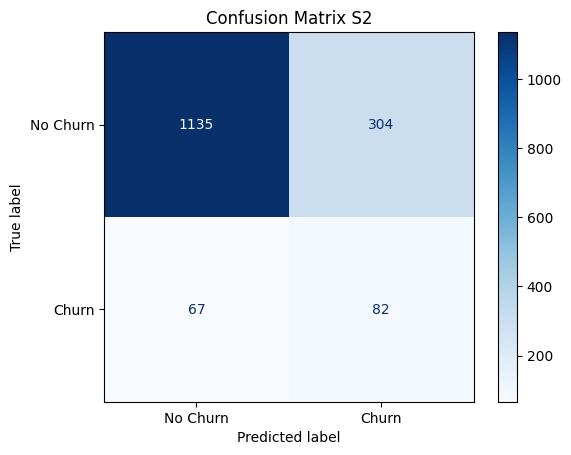

In [21]:
# Display confusion matrix S2
conf_matrix_S2 = confusion_matrix(y_test, y_pred_S2)
disp_S2 = ConfusionMatrixDisplay(conf_matrix_S2, display_labels=['No Churn','Churn'])
disp_S2.plot(cmap='Blues')
plt.title('Confusion Matrix S2')
plt.show()

In [22]:
# Values for false positive (fp_S2), false negative (fn_S2), true positive (tp_S2) and true negative (tn_S2)
fp_S2 = conf_matrix_S2[0][1]
fn_S2 = conf_matrix_S2[1][0]
tp_S2 = conf_matrix_S2[1][1]
tn_S2 = conf_matrix_S2[0][0]

print(f' fp_S2: {fp_S2} \n fn_S2: {fn_S2} \n tp_S2: {tp_S2} \n tn_S2: {tn_S2}')

 fp_S2: 304 
 fn_S2: 67 
 tp_S2: 82 
 tn_S2: 1135


In [23]:
# Calculations for accuracy, precision, recall
accuracy_S2 = (tp_S2 + tn_S2)/len(y_test)
precision_S2 = tp_S2/(tp_S2 + fp_S2)
recall_S2 = tp_S2/(tp_S2 + fn_S2)

print(f'Accuracy_S2: {accuracy_S2:.2f}')
print(f'Precision_S2: {precision_S2:.2f}')
print(f'Recall_S2: {recall_S2:.2f}')
print(f'-'*18)

Accuracy_S2: 0.77
Precision_S2: 0.21
Recall_S2: 0.55
------------------


In [24]:
# Calculate F2 score for Model S2
beta = 2
F2_score_S2 = (1 + beta**2) * (precision_S2 * recall_S2) / (beta**2 * precision_S2 + recall_S2)

print(f'The F2 score for Model S2 is {F2_score_S2:.4f}')

The F2 score for Model S2 is 0.4175


**Profit/Loss analysis**     
The profit/loss analysis compares the relative performance of the models financially. For demonstration purposes, the following values are used:     
**L** = value of retaining a churner (lifetime value) is \$500      
**C** = cost of retention action is \$40     
True positives (**TP**) are correctly identified churners (retention action is spent but the value is saved).   
False positives (**FP**) stay but predicted to leave (retention action is spent but no value is saved).    
False negatives (**FN)** are predicted not to leave but leave (no retention action spent but value is lost).    
True negatives (**TN**) are correctly predicted not to leave (no retention action spent and no value is lost).

In [25]:
# Profit/loss analysis for Model S2
L=500
C=40
Profit_Loss_S2 = tp_S2*(L - C) - fp_S2*C - fn_S2*L

print(f'The profit or loss is ${Profit_Loss_S2}')

The profit or loss is $-7940


**Model S3** uses the threshold that maximizes profit. While the optimal threshold from the ROC Curve increases recall, it does not maximize profit.

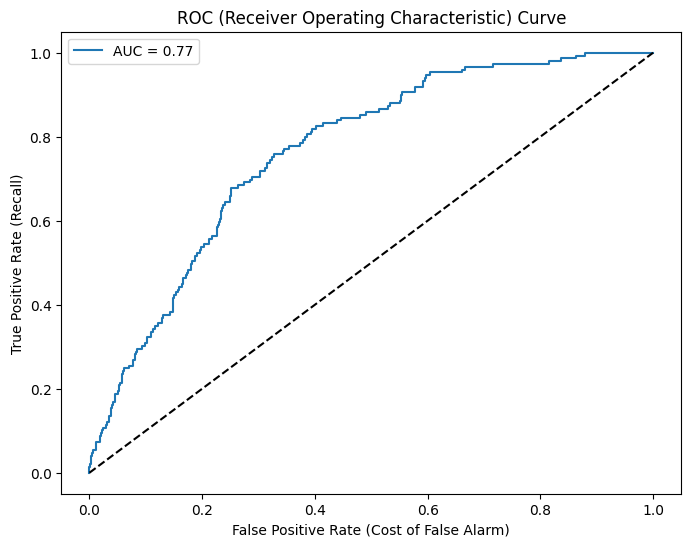

In [26]:
# Plot the ROC Curve
y_probs_S3 = grid_svc_S2_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_S3)
auc_S3 = round(roc_auc_score(y_test, y_probs_S3), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_S3):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [27]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_S3 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_S3 :.2f}')

The optimal threshold is 0.09


In [28]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_S3)
avg_precision = average_precision_score(y_test, y_probs_S3)

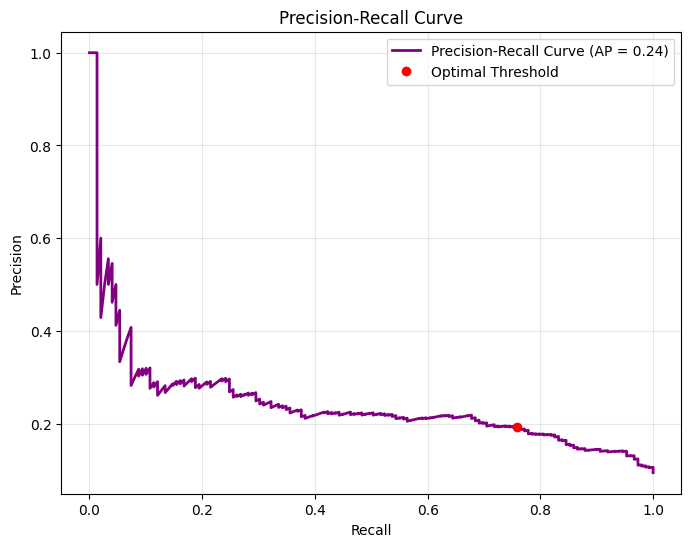

In [29]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_S3))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal Threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [30]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.5, 0.05)
for threshold in thresholds:
    preds = (y_probs_S3 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.09 | Recall=1.00
Threshold=0.05 | Precision=0.14 | Recall=0.95
Threshold=0.10 | Precision=0.20 | Recall=0.70
Threshold=0.15 | Precision=0.22 | Recall=0.44
Threshold=0.20 | Precision=0.26 | Recall=0.30
Threshold=0.25 | Precision=0.29 | Recall=0.21
Threshold=0.30 | Precision=0.27 | Recall=0.13
Threshold=0.35 | Precision=0.31 | Recall=0.10
Threshold=0.40 | Precision=0.36 | Recall=0.06
Threshold=0.45 | Precision=0.44 | Recall=0.05


In [31]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_S3 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.05


In [32]:
# Define the Model S3 threshold
threshold_S3 = best_threshold

In [33]:
# Use the best threshold
y_pred_S3 = (y_probs_S3 >= threshold_S3).astype(int)

In [34]:
# Generate classification report S3

print(classification_report(y_test, y_pred_S3))

              precision    recall  f1-score   support

           0       0.99      0.39      0.56      1439
           1       0.14      0.95      0.24       149

    accuracy                           0.44      1588
   macro avg       0.56      0.67      0.40      1588
weighted avg       0.91      0.44      0.53      1588



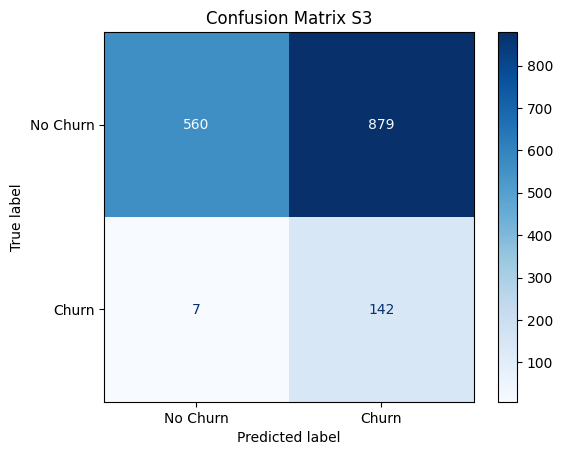

In [35]:
# Display confusion matrix S3
conf_matrix_S3 = confusion_matrix(y_test, y_pred_S3)
disp_S3 = ConfusionMatrixDisplay(conf_matrix_S3, display_labels=['No Churn','Churn'])
disp_S3.plot(cmap='Blues')
plt.title('Confusion Matrix S3')
plt.show()

In [36]:
# Values for false positive (fp_S3), false negative (fn_S3), true positive (tp_S3) and true negative (tn_S3)
fp_S3 = conf_matrix_S3[0][1]
fn_S3 = conf_matrix_S3[1][0]
tp_S3 = conf_matrix_S3[1][1]
tn_S3 = conf_matrix_S3[0][0]

print(f' fp_S3: {fp_S3} \n fn_S3: {fn_S3} \n tp_S3: {tp_S3} \n tn_S3: {tn_S3}')

 fp_S3: 879 
 fn_S3: 7 
 tp_S3: 142 
 tn_S3: 560


In [37]:
# Calculations for accuracy, precision, recall
accuracy_S3 = (tp_S3 + tn_S3)/len(y_test)
precision_S3 = tp_S3/(tp_S3 + fp_S3)
recall_S3 = tp_S3/(tp_S3 + fn_S3)

print(f'Accuracy_S3: {accuracy_S3:.2f}')
print(f'Precision_S3: {precision_S3:.2f}')
print(f'Recall_S3: {recall_S3:.2f}')
print(f'-'*21)

Accuracy_S3: 0.44
Precision_S3: 0.14
Recall_S3: 0.95
---------------------


In [38]:
# Calculate F2 score for Model S3
beta = 2
F2_score_S3 = (1 + beta**2) * (precision_S3 * recall_S3) / (beta**2 * precision_S3 + recall_S3)

print(f'The F2 score for Model S3 is {F2_score_S3:.4f}')

The F2 score for Model S3 is 0.4391


In [39]:
# Profit/loss analysis for Model S3
Profit_Loss_S3 = tp_S3*(L - C) - fp_S3*C - fn_S3*L

print(f'The profit or loss is ${Profit_Loss_S3}')

The profit or loss is $26660


**Feature Importance Model S3**         
**csat_score** is the most important feature and is the strongest predictor of churn. Lower score increases the churn probability. In order to reduce churn, satisfaction should be improved.     
**monthly_logins** is the second most important feature. Customers who log in less frequently are more likely to churn. Customers with high engagement have low churn risk.     
**payment_failures** Customers experiencing payment issues are at a higher risk of churn. Billing friction or financial dissatisfaction could be an issue.

In [40]:
# Use permutation importance
result = permutation_importance(
    grid_svc_S2_opt,
    X_test,
    y_test,
    n_repeats=20,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [41]:
# Interpret the results
S3_feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': result.importances_mean
}).sort_values(by='importance_mean', ascending=False)

# Reset index
S3_feature_importance_df = S3_feature_importance_df.reset_index(drop=True)
S3_feature_importance_df.index = S3_feature_importance_df.index + 1
S3_feature_importance_df.index.name = "Rank"

S3_feature_importance_df.head(10)

,feature,importance_mean
Rank,,
1,csat_score,0.068526
2,payment_failures,0.035504
3,monthly_logins,0.012676
4,tenure_months,0.012279
5,avg_session_time,0.008833
6,age,0.004757
7,tenure_fee_interaction,0.003949
8,avg_resolution_time,0.003791
9,customer_segment,0.003198


In [42]:
# Select the first twenty features
S3_feature_importance_df = S3_feature_importance_df.iloc[:20]

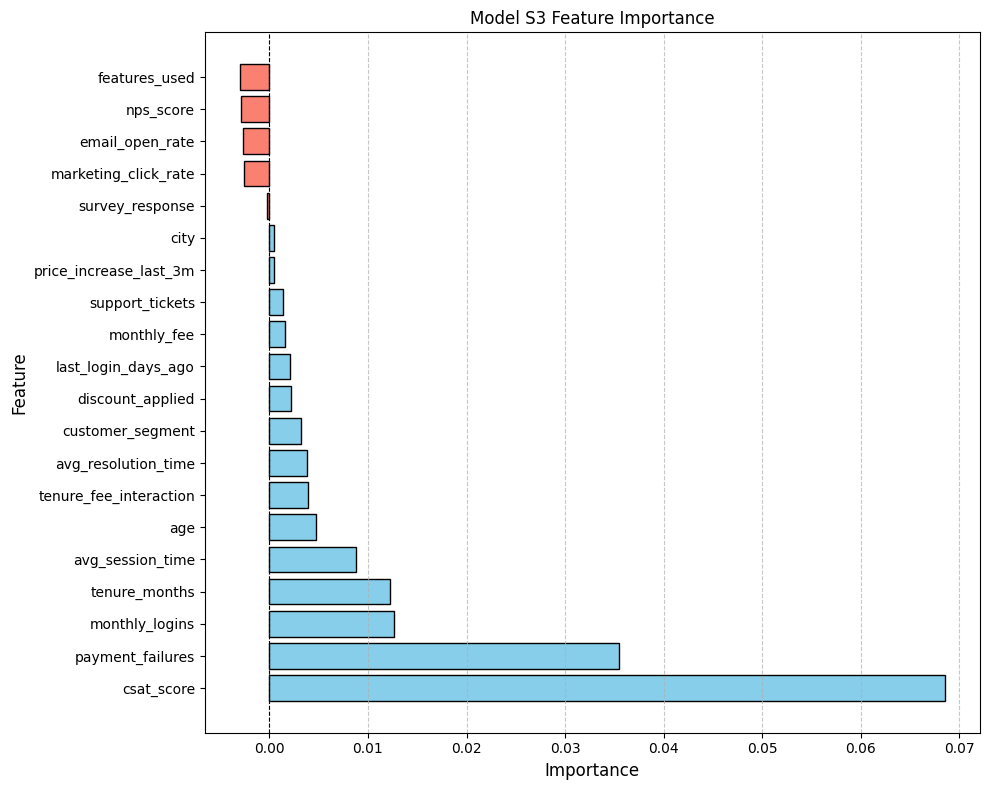

In [43]:
# Plot the important features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in S3_feature_importance_df['importance_mean']]
plt.barh(S3_feature_importance_df['feature'], S3_feature_importance_df['importance_mean'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Model S3 Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Selection**    
**Model S4** uses SelectKBest to select the top features.

In [44]:
# Obtain the best number of features based on AUC
auc=[]
features = np.arange(17, 26, 3)
for i in features:
  # Set up selector
  selector = SelectKBest(
      score_func=mutual_info_classif,
      k=i
  )
  # Build the pipeline
  svc_pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('select', selector),
      ('svc', SVC(class_weight='balanced', probability=True, random_state=42))
  ])
  svc_pipe.fit(X_train, y_train)
  # Define parameter grid
  param_grid = {
      'svc__C': [0.01, 0.1, 0.5],
      'svc__kernel': ['linear', 'rbf', 'poly'],
      'svc__gamma': ['scale', 0.001, 0.01]
  }
  # Run RandomizedSearchCV
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  grid_svc = RandomizedSearchCV(
      estimator=svc_pipe,
      param_distributions=param_grid,
      cv=cv,
      scoring='f1',
      n_jobs=-1,
      verbose=2
  )
  grid_svc.fit(X_train, y_train)
  # Access the optimized pipeline model
  grid_svc_opt = grid_svc.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_svc_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Number of Features = 17 | AUC = 0.7697
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Number of Features = 20 | AUC = 0.8199
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Number of Features = 23 | AUC = 0.7663


In [45]:
# Determine best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 20.


In [46]:
# Set up selector on best number of features
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=best_features
)

In [47]:
# Build the pipeline
svc_pipe_S4 = Pipeline([
    ('preprocessor', preprocessor),
    ('select', selector),
    ('svc', SVC(class_weight='balanced', probability=True, random_state=42))
])
svc_pipe_S4.fit(X_train, y_train)
svc_pipe_S4

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment...
                                                   'payment_failures',
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('select',
                 SelectKBest(k=np.int64(20),
                             score_func=<function mutual_info_classif at 0x7d81544b65c0>)),
                ('svc',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [48]:
# Define parameter grid
param_grid_S4 = {
    'svc__C': [0.01, 0.1, 0.5],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ['scale', 0.001, 0.01]
}

In [49]:
# Run RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_svc_S4 = RandomizedSearchCV(
    estimator=svc_pipe_S4,
    param_distributions=param_grid_S4,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)
grid_svc_S4.fit(X_train, y_train)

print(f'The best parameters are {grid_svc_S4.best_params_}')
print(f'The best score is {grid_svc_S4.best_score_:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best parameters are {'svc__kernel': 'poly', 'svc__gamma': 'scale', 'svc__C': 0.01}
The best score is 0.3253


In [50]:
# Access the optimized pipeline model
grid_svc_S4_opt = grid_svc_S4.best_estimator_
grid_svc_S4_opt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment...
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('select',
                 SelectKBest(k=np.int64(20),
                             score_func=<function mutual_info_classif at 0x7d81544b65c0>)),
                ('svc',
                 SVC(C=0.01, class_weight='balanced', kernel='poly',
                     probability=True, random_state=42))])

In [51]:
# Accuracy on train and test data
grid_svc_S4_opt_acc_train = grid_svc_S4_opt.score(X_train, y_train)
grid_svc_S4_opt_acc_test = grid_svc_S4_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_svc_S4_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_svc_S4_opt_acc_test*100:.2f}%')

The train accuracy of the model is 81.27%
The test accuracy of the model is 79.35%


In [52]:
# Generate classification report S4
y_pred_S4 = grid_svc_S4_opt.predict(X_test)

print(classification_report(y_test, y_pred_S4))

              precision    recall  f1-score   support

           0       0.95      0.82      0.88      1439
           1       0.24      0.54      0.33       149

    accuracy                           0.79      1588
   macro avg       0.59      0.68      0.60      1588
weighted avg       0.88      0.79      0.83      1588



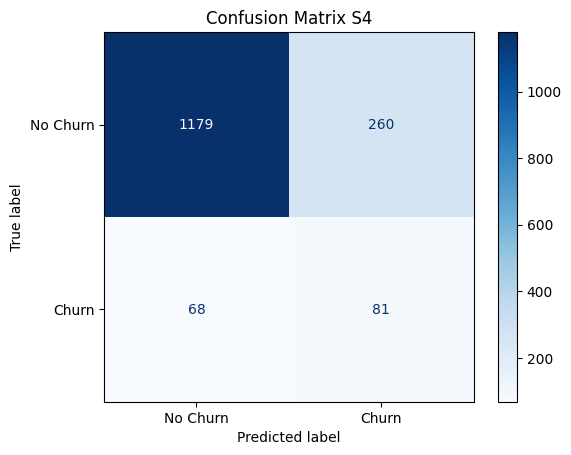

In [53]:
# Display confusion matrix
conf_matrix_S4 = confusion_matrix(y_test, y_pred_S4)
disp_S4 = ConfusionMatrixDisplay(conf_matrix_S4, display_labels=['No Churn','Churn'])
disp_S4.plot(cmap='Blues')
plt.title('Confusion Matrix S4')
plt.show()

In [54]:
# Values for false positive (fp_S4), false negative (fn_S4), true positive (tp_S4) and true negative (tn_S4)
fp_S4 = conf_matrix_S4[0][1]
fn_S4 = conf_matrix_S4[1][0]
tp_S4 = conf_matrix_S4[1][1]
tn_S4 = conf_matrix_S4[0][0]

print(f' fp_S4: {fp_S4} \n fn_S4: {fn_S4} \n tp_S4: {tp_S4} \n tn_S4: {tn_S4}')

 fp_S4: 260 
 fn_S4: 68 
 tp_S4: 81 
 tn_S4: 1179


In [55]:
# Calculations for accuracy, precision, recall
accuracy_S4 = (tp_S4 + tn_S4)/len(y_test)
precision_S4 = tp_S4/(tp_S4 + fp_S4)
recall_S4 = tp_S4/(tp_S4 + fn_S4)

print(f'Accuracy: {accuracy_S4:.2f}')
print(f'Precision: {precision_S4:.2f}')
print(f'Recall: {recall_S4:.2f}')
print(f'-'*15)

Accuracy: 0.79
Precision: 0.24
Recall: 0.54
---------------


In [56]:
# Calculate F2 score
beta = 2
F2_score_S4 = (1 + beta**2) * (precision_S4 * recall_S4) / (beta**2 * precision_S4 + recall_S4)

print(f'The F2 score is {F2_score_S4:.4f}')

The F2 score is 0.4322


In [57]:
# Profit/loss analysis
Profit_Loss_S4 = tp_S4*(L - C) - fp_S4*C - fn_S4*L

print(f'The profit or loss is ${Profit_Loss_S4}')

The profit or loss is $-7140


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

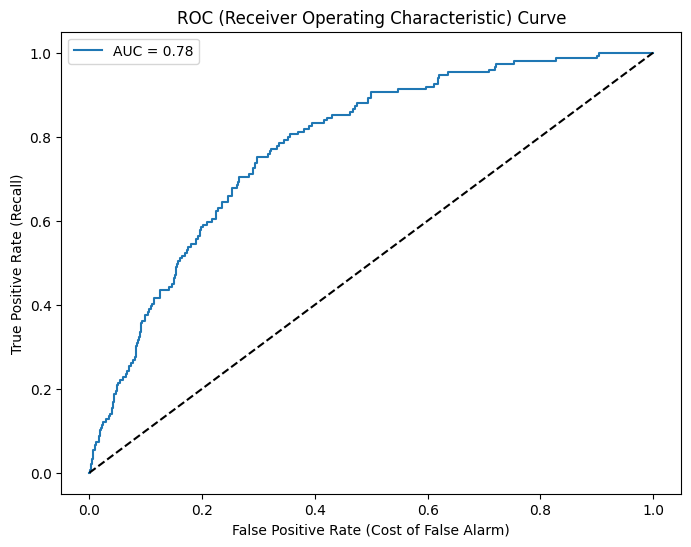

In [58]:
# Plot the ROC Curve
y_probs_S4 = grid_svc_S4_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_S4)
auc_S4 = round(roc_auc_score(y_test, y_probs_S4), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_S4):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [59]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_S4 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_S4 :.4f}')

The optimal threshold is 0.0899


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [60]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_S4)
avg_precision = average_precision_score(y_test, y_probs_S4)

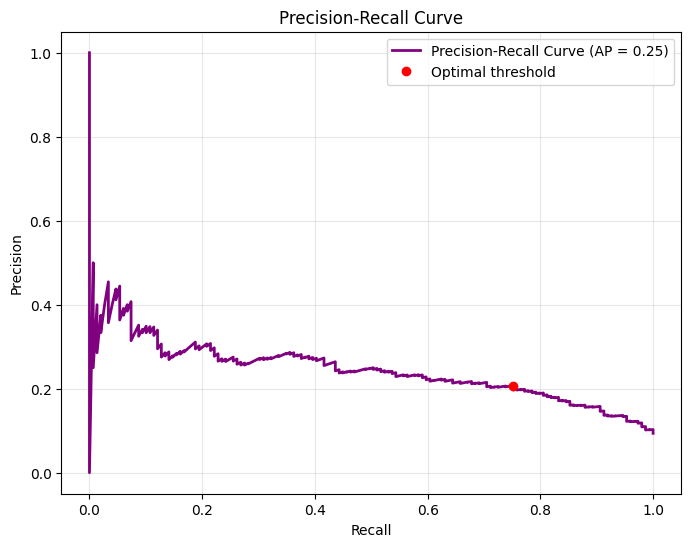

In [61]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_S4))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [62]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_S4 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.09 | Recall=1.00
Threshold=0.05 | Precision=0.13 | Recall=0.93
Threshold=0.10 | Precision=0.21 | Recall=0.69
Threshold=0.15 | Precision=0.24 | Recall=0.45
Threshold=0.20 | Precision=0.27 | Recall=0.32
Threshold=0.25 | Precision=0.29 | Recall=0.22
Threshold=0.30 | Precision=0.29 | Recall=0.16
Threshold=0.35 | Precision=0.29 | Recall=0.13
Threshold=0.40 | Precision=0.33 | Recall=0.11
Threshold=0.45 | Precision=0.34 | Recall=0.09
Threshold=0.50 | Precision=0.37 | Recall=0.07
Threshold=0.55 | Precision=0.39 | Recall=0.06
Threshold=0.60 | Precision=0.40 | Recall=0.04
Threshold=0.65 | Precision=0.33 | Recall=0.02
Threshold=0.70 | Precision=0.40 | Recall=0.01
Threshold=0.75 | Precision=0.33 | Recall=0.01


In [63]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_S4 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.05


In [64]:
# Define threshold_S4
threshold_S4 = best_threshold

In [65]:
# Use the threshold that maximizes profit
y_pred_S4 = (y_probs_S4 >= best_threshold).astype(int)

In [66]:
# Generate classification report S4

print(classification_report(y_test, y_pred_S4))

              precision    recall  f1-score   support

           0       0.98      0.38      0.55      1439
           1       0.13      0.93      0.24       149

    accuracy                           0.43      1588
   macro avg       0.56      0.66      0.39      1588
weighted avg       0.90      0.43      0.52      1588



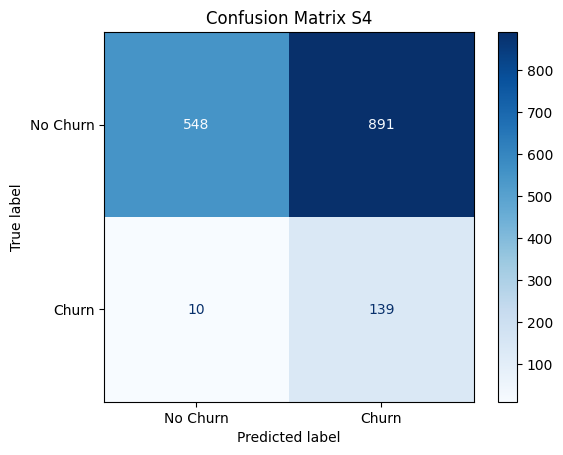

In [67]:
# Display confusion matrix S4
conf_matrix_S4 = confusion_matrix(y_test, y_pred_S4)
disp_S4 = ConfusionMatrixDisplay(conf_matrix_S4, display_labels=['No Churn','Churn'])
disp_S4.plot(cmap='Blues')
plt.title('Confusion Matrix S4')
plt.show()

In [68]:
# Values for false positive (fp_S4), false negative (fn_S4), true positive (tp_S4) and true negative (tn_S4)
fp_S4 = conf_matrix_S4[0][1]
fn_S4 = conf_matrix_S4[1][0]
tp_S4 = conf_matrix_S4[1][1]
tn_S4 = conf_matrix_S4[0][0]

print(f' fp_S4: {fp_S4} \n fn_S4: {fn_S4} \n tp_S4: {tp_S4} \n tn_S4: {tn_S4}')

 fp_S4: 891 
 fn_S4: 10 
 tp_S4: 139 
 tn_S4: 548


In [69]:
# Calculations for accuracy, precision, recall
accuracy_S4 = (tp_S4 + tn_S4)/len(y_test)
precision_S4 = tp_S4/(tp_S4 + fp_S4)
recall_S4 = tp_S4/(tp_S4 + fn_S4)

print(f'Accuracy: {accuracy_S4:.2f}')
print(f'Precision: {precision_S4:.2f}')
print(f'Recall: {recall_S4:.2f}')
print(f'-'*15)

Accuracy: 0.43
Precision: 0.13
Recall: 0.93
---------------


In [70]:
# Calculate F2 score
beta = 2
F2_score_S4 = (1 + beta**2) * (precision_S4 * recall_S4) / (beta**2 * precision_S4 + recall_S4)

print(f'The F2 score is {F2_score_S4:.4f}')

The F2 score is 0.4274


In [71]:
# Profit/loss analysis
Profit_Loss_S4 = tp_S4*(L - C) - fp_S4*C - fn_S4*L

print(f'The profit or loss is ${Profit_Loss_S4}')

The profit or loss is $23300


**Feature Importance Model S4**      
The model finds the features **csat_score**, **payment_failures**,**tenure_months**, and **monthly_logins** to be highly important.



In [72]:
# Extract selector from pipeline
selector = svc_pipe_S4.named_steps["select"]
mask = selector.get_support()

In [73]:
# Get selected features names
feature_names = svc_pipe_S4.named_steps["preprocessor"].get_feature_names_out()
selected_features = feature_names[mask]

print(f'There are {len(selected_features)} selected features.')

There are 20 selected features.


In [74]:
# Get feature scores
scores = selector.scores_

In [75]:
# Combine with feature names
feature_scores_df = pd.DataFrame({
    "feature": feature_names,
    "importance": scores
}).sort_values(by="importance", ascending=False)

print(feature_scores_df.head(20))

                            feature  importance
35               num__tenure_months    0.027805
46                  num__csat_score    0.020484
52      num__tenure_fee_interaction    0.013464
43            num__payment_failures    0.013218
29   nom__price_increase_last_3m_No    0.012322
36              num__monthly_logins    0.009105
12                  nom__city_Delhi    0.007403
7              nom__country_Germany    0.006924
22     nom__signup_channel_Referral    0.006102
51              num__referral_count    0.004763
9                   nom__country_UK    0.004330
0                ord__contract_type    0.003843
16                 nom__city_Sydney    0.003755
32      nom__complaint_type_Service    0.003688
30  nom__price_increase_last_3m_Yes    0.003620
5           nom__country_Bangladesh    0.003420
28        nom__discount_applied_Yes    0.003405
50                   num__nps_score    0.003154
34                         num__age    0.003009
4            nom__country_Australia    0

In [76]:
# Show only selected features
S4_feature_importance_df = feature_scores_df[feature_scores_df["feature"].isin(selected_features)]
S4_feature_importance_df["feature"] = S4_feature_importance_df["feature"].apply(lambda x: x.split('__')[-1]) # Clean feature names

print(S4_feature_importance_df, '\n')
print(f'There are {len(S4_feature_importance_df)} selected features.')

                       feature  importance
35               tenure_months    0.027805
46                  csat_score    0.020484
52      tenure_fee_interaction    0.013464
43            payment_failures    0.013218
29   price_increase_last_3m_No    0.012322
36              monthly_logins    0.009105
12                  city_Delhi    0.007403
7              country_Germany    0.006924
22     signup_channel_Referral    0.006102
51              referral_count    0.004763
9                   country_UK    0.004330
0                contract_type    0.003843
16                 city_Sydney    0.003755
32      complaint_type_Service    0.003688
30  price_increase_last_3m_Yes    0.003620
5           country_Bangladesh    0.003420
28        discount_applied_Yes    0.003405
50                   nps_score    0.003154
34                         age    0.003009
4            country_Australia    0.002586 

There are 20 selected features.


In [77]:
# Reset index to show features ranking
S4_feature_importance_df = S4_feature_importance_df.reset_index(drop=True)
S4_feature_importance_df.index = S4_feature_importance_df.index + 1
S4_feature_importance_df.index.name = "Rank"

S4_feature_importance_df.head(10)

,feature,importance
Rank,,
1,tenure_months,0.027805
2,csat_score,0.020484
3,tenure_fee_interaction,0.013464
4,payment_failures,0.013218
5,price_increase_last_3m_No,0.012322
6,monthly_logins,0.009105
7,city_Delhi,0.007403
8,country_Germany,0.006924
9,signup_channel_Referral,0.006102


In [78]:
# Select the first twenty features
S4_feature_importance_df = S4_feature_importance_df.iloc[:20]

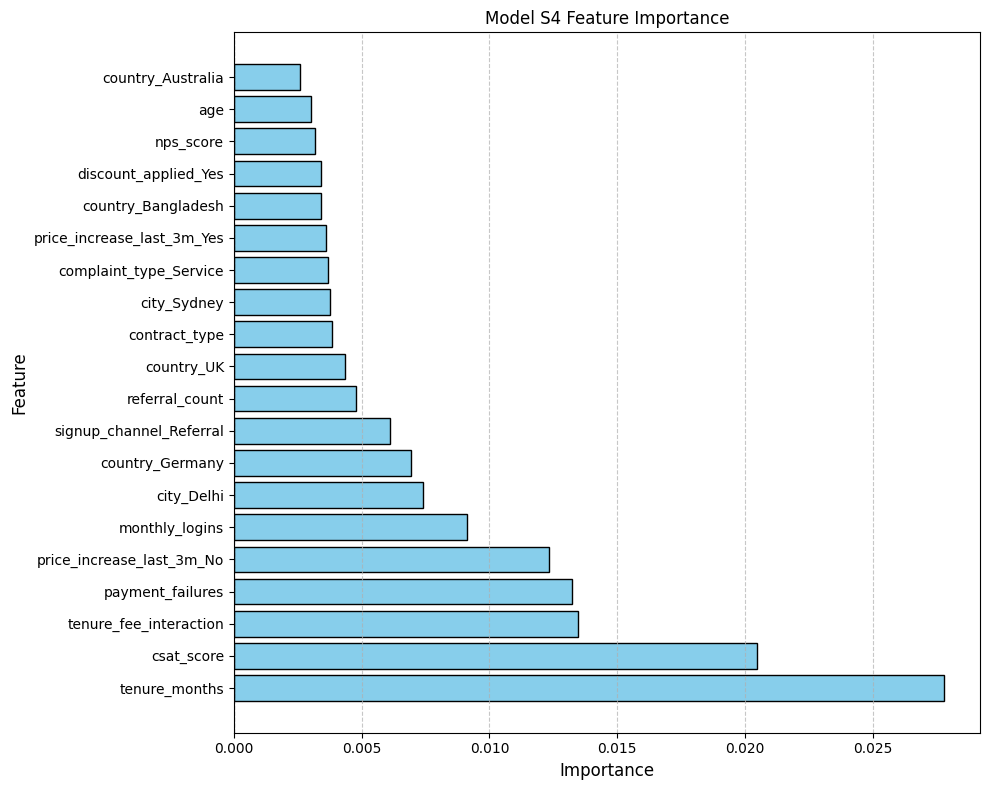

In [79]:
# Plot the important features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in S4_feature_importance_df['importance']]
plt.barh(S4_feature_importance_df['feature'], S4_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Model S4 Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Feature Selection**   
**Model S5** uses Random Forest Classifier to select the top features.

In [134]:
# Obtain the best number of features based on AUC
auc=[]
features = np.arange(34, 40, 2)
for i in features:
  # Build the pipeline
  svc_pipe = Pipeline([
      ('preprocessor', preprocessor),
      ('select', SelectFromModel(RandomForestClassifier(random_state=42), max_features=i,
          threshold=-float("inf"))),   # ensures exactly the number of features
      ('svc', SVC(class_weight='balanced', probability=True, random_state=42))
  ])
  svc_pipe.fit(X_train, y_train)
  # Define parameter grid
  param_grid = {
      'svc__C': [0.01, 0.1, 0.5],
      'svc__kernel': ['linear', 'rbf', 'poly'],
      'svc__gamma': ['scale', 0.001, 0.01]
  }
  # Run RandomizedSearchCV
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  grid_svc = RandomizedSearchCV(
      estimator=svc_pipe,
      param_distributions=param_grid,
      cv=cv,
      scoring='f1',
      n_jobs=-1,
      verbose=2
  )
  grid_svc.fit(X_train, y_train)
  # Access the optimized pipeline model
  grid_svc_opt = grid_svc.best_estimator_
  # Evaluate 'roc_auc_score'
  y_proba = grid_svc_opt.predict_proba(X_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_proba)
  auc.append(roc_auc)
  print(f'Number of Features = {i} | AUC = {roc_auc:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Number of Features = 34 | AUC = 0.7759
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Number of Features = 36 | AUC = 0.7663
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Number of Features = 38 | AUC = 0.7819


In [135]:
# Determine best number of features
best_features = features[np.argmax(auc)]

print(f'The best number of features is {best_features}.')

The best number of features is 38.


In [136]:
# Build the pipeline
svc_pipe_S5 = Pipeline([
    ('preprocessor', preprocessor),
    ('select', SelectFromModel(RandomForestClassifier(random_state=42), max_features=best_features,
        threshold=-float("inf"))),
    ('svc', SVC(class_weight='balanced', probability=True, random_state=42))
])
svc_pipe_S5.fit(X_train, y_train)
svc_pipe_S5

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment...
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('select',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 max_features=np.int64(38), threshold=-inf)),
                ('svc',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [137]:
# Define parameter grid
param_grid_S5 = {
    'svc__C': [0.01, 0.1, 0.5],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ['scale', 0.001, 0.01]
}

In [138]:
# Run RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_svc_S5 = RandomizedSearchCV(
    estimator=svc_pipe_S5,
    param_distributions=param_grid_S5,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)
grid_svc_S5.fit(X_train, y_train)

print(f'The best parameters are {grid_svc_S5.best_params_}')
print(f'The best score is {grid_svc_S5.best_score_:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best parameters are {'svc__kernel': 'rbf', 'svc__gamma': 'scale', 'svc__C': 0.5}
The best score is 0.3149


In [139]:
# Access the optimized pipeline model
grid_svc_S5_opt = grid_svc_S5.best_estimator_
grid_svc_S5_opt

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Monthly',
                                                                              'Quarterly',
                                                                              'Yearly'],
                                                                             ['Unsatisfied',
                                                                              'Neutral',
                                                                              'Satisfied']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['contract_type',
                                                   'survey_response']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'country', 'city',
                                                   'customer_segment...
                                                   'support_tickets',
                                                   'avg_resolution_time',
                                                   'csat_score', 'escalations',
                                                   'email_open_rate',
                                                   'marketing_click_rate',
                                                   'nps_score',
                                                   'referral_count',
                                                   'tenure_fee_interaction'])])),
                ('select',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=42),
                                 max_features=np.int64(38), threshold=-inf)),
                ('svc',
                 SVC(C=0.5, class_weight='balanced', probability=True,
                     random_state=42))])

In [140]:
# Accuracy on train and test data
grid_svc_S5_opt_acc_train = grid_svc_S5_opt.score(X_train, y_train)
grid_svc_S5_opt_acc_test = grid_svc_S5_opt.score(X_test, y_test)

print(f'The train accuracy of the model is {grid_svc_S5_opt_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {grid_svc_S5_opt_acc_test*100:.2f}%')

The train accuracy of the model is 81.41%
The test accuracy of the model is 75.00%


In [141]:
# Generate classification report S5
y_pred_S5 = grid_svc_S5_opt.predict(X_test)

print(classification_report(y_test, y_pred_S5))

              precision    recall  f1-score   support

           0       0.95      0.76      0.85      1439
           1       0.22      0.64      0.32       149

    accuracy                           0.75      1588
   macro avg       0.58      0.70      0.59      1588
weighted avg       0.88      0.75      0.80      1588



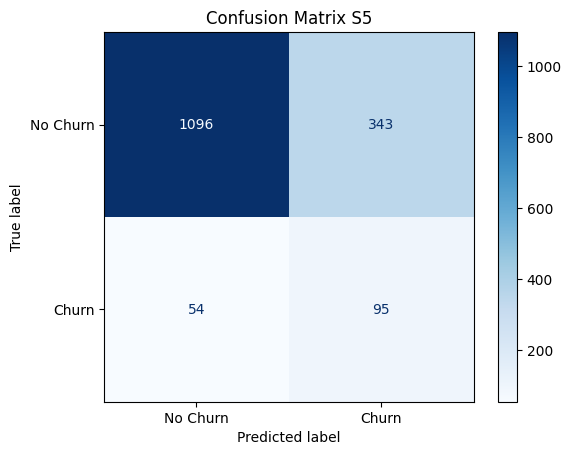

In [142]:
# Display confusion matrix
conf_matrix_S5 = confusion_matrix(y_test, y_pred_S5)
disp_S5 = ConfusionMatrixDisplay(conf_matrix_S5, display_labels=['No Churn','Churn'])
disp_S5.plot(cmap='Blues')
plt.title('Confusion Matrix S5')
plt.show()

In [143]:
# Values for false positive (fp_S5), false negative (fn_S5), true positive (tp_S5) and true negative (tn_S5)
fp_S5 = conf_matrix_S5[0][1]
fn_S5 = conf_matrix_S5[1][0]
tp_S5 = conf_matrix_S5[1][1]
tn_S5 = conf_matrix_S5[0][0]

print(f' fp_S5: {fp_S5} \n fn_S5: {fn_S5} \n tp_S5: {tp_S5} \n tn_S5: {tn_S5}')

 fp_S5: 343 
 fn_S5: 54 
 tp_S5: 95 
 tn_S5: 1096


In [144]:
# Calculations for accuracy, precision, recall
accuracy_S5 = (tp_S5 + tn_S5)/len(y_test)
precision_S5 = tp_S5/(tp_S5 + fp_S5)
recall_S5 = tp_S5/(tp_S5 + fn_S5)

print(f'Accuracy: {accuracy_S5:.2f}')
print(f'Precision: {precision_S5:.2f}')
print(f'Recall: {recall_S5:.2f}')
print(f'-'*15)

Accuracy: 0.75
Precision: 0.22
Recall: 0.64
---------------


In [145]:
# Calculate F2 score
beta = 2
F2_score_S5 = (1 + beta**2) * (precision_S5 * recall_S5) / (beta**2 * precision_S5 + recall_S5)

print(f'The F2 score is {F2_score_S5:.4f}')

The F2 score is 0.4594


In [146]:
# Profit/loss analysis
Profit_Loss_S5 = tp_S5*(L - C) - fp_S5*C - fn_S5*L

print(f'The profit or loss is ${Profit_Loss_S5}')

The profit or loss is $2980


**ROC Curve**    
The ROC Curve is plotted and the optimum threshold is obtained.

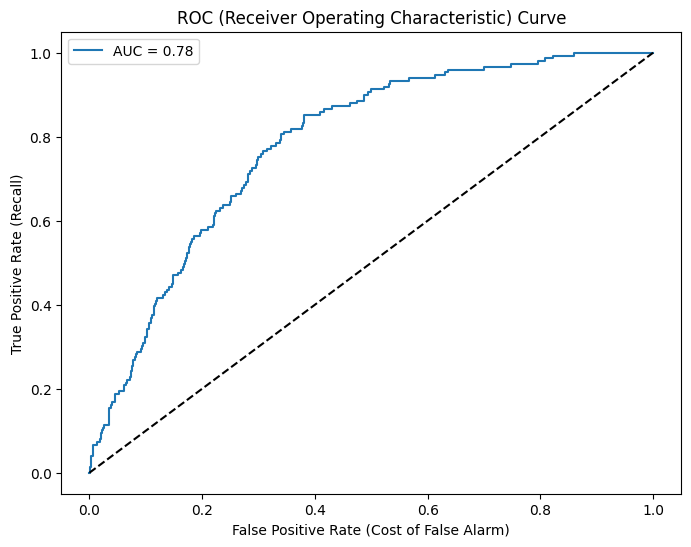

In [147]:
# Plot the ROC Curve
y_probs_S5 = grid_svc_S5_opt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_S5)
auc_S5 = round(roc_auc_score(y_test, y_probs_S5), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs_S5):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [148]:
# Find the optimal threshold from the ROC Curve that maximizes Youden's J
optimal_idx = np.argmax(tpr-fpr)
optimal_threshold_S5 = thresholds[optimal_idx]

print(f'The optimal threshold is {optimal_threshold_S5 :.4f}')

The optimal threshold is 0.0805


**Threshold that maximizes profit**    
The threshold that maximizes profit is obtained from the precision-recall curve

In [149]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_S5)
avg_precision = average_precision_score(y_test, y_probs_S5)

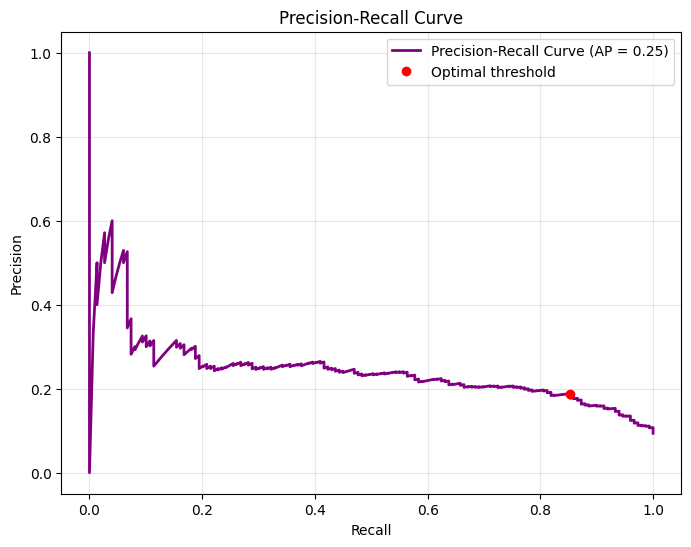

In [150]:
# Plot the precision-recall curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
# Mark the optimal threshold on the plot
idx = np.argmin(np.abs(thresholds-optimal_threshold_S5))
plt.plot(recall[idx], precision[idx], 'ro', label='Optimal threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [151]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.80, 0.05)
for threshold in thresholds:
    preds = (y_probs_S5 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.09 | Recall=1.00
Threshold=0.05 | Precision=0.15 | Recall=0.94
Threshold=0.10 | Precision=0.21 | Recall=0.74
Threshold=0.15 | Precision=0.24 | Recall=0.54
Threshold=0.20 | Precision=0.25 | Recall=0.34
Threshold=0.25 | Precision=0.25 | Recall=0.22
Threshold=0.30 | Precision=0.31 | Recall=0.15
Threshold=0.35 | Precision=0.32 | Recall=0.09
Threshold=0.40 | Precision=0.45 | Recall=0.07
Threshold=0.45 | Precision=0.55 | Recall=0.04
Threshold=0.50 | Precision=0.57 | Recall=0.03
Threshold=0.55 | Precision=0.33 | Recall=0.01
Threshold=0.60 | Precision=0.00 | Recall=0.00
Threshold=0.65 | Precision=0.00 | Recall=0.00
Threshold=0.70 | Precision=0.00 | Recall=0.00
Threshold=0.75 | Precision=0.00 | Recall=0.00


In [152]:
# Determine the threshold that maximizes profit
profits = []
for t in thresholds:
    y_pred = (y_probs_S5 >= t).astype(int)
    conf_matrix = confusion_matrix(y_test, y_pred)
    fp = conf_matrix[0][1]
    fn = conf_matrix[1][0]
    tp = conf_matrix[1][1]
    Profit_Loss = tp*(L - C) - fp*C - fn*L
    profits.append(Profit_Loss)

best_threshold = thresholds[np.argmax(profits)]

print(f'The threshold that maximizes profit is {best_threshold}')

The threshold that maximizes profit is 0.05


In [153]:
# Define threshold S5
threshold_S5 = best_threshold

In [154]:
# Use the threshold that maximizes profit
y_pred_S5 = (y_probs_S5 >= best_threshold).astype(int)

In [155]:
# Generate classification report

print(classification_report(y_test, y_pred_S5))

              precision    recall  f1-score   support

           0       0.99      0.43      0.60      1439
           1       0.15      0.94      0.25       149

    accuracy                           0.48      1588
   macro avg       0.57      0.68      0.42      1588
weighted avg       0.91      0.48      0.56      1588



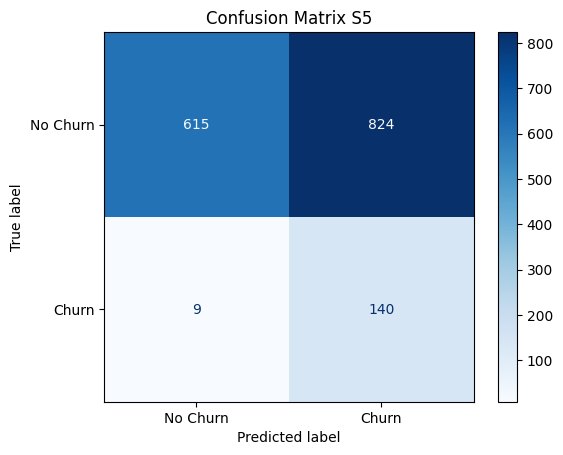

In [156]:
# Display confusion matrix
conf_matrix_S5 = confusion_matrix(y_test, y_pred_S5)
disp_S5 = ConfusionMatrixDisplay(conf_matrix_S5, display_labels=['No Churn','Churn'])
disp_S5.plot(cmap='Blues')
plt.title('Confusion Matrix S5')
plt.show()

In [157]:
# Values for false positive (fp_S5), false negative (fn_S5), true positive (tp_S5) and true negative (tn_S5)
fp_S5 = conf_matrix_S5[0][1]
fn_S5 = conf_matrix_S5[1][0]
tp_S5 = conf_matrix_S5[1][1]
tn_S5 = conf_matrix_S5[0][0]

print(f' fp_S5: {fp_S5} \n fn_S5: {fn_S5} \n tp_S5: {tp_S5} \n tn_S5: {tn_S5}')

 fp_S5: 824 
 fn_S5: 9 
 tp_S5: 140 
 tn_S5: 615


In [158]:
# Calculations for accuracy, precision, recall
accuracy_S5 = (tp_S5 + tn_S5)/len(y_test)
precision_S5 = tp_S5/(tp_S5 + fp_S5)
recall_S5 = tp_S5/(tp_S5 + fn_S5)

print(f'Accuracy: {accuracy_S5:.2f}')
print(f'Precision: {precision_S5:.2f}')
print(f'Recall: {recall_S5:.2f}')
print(f'-'*15)

Accuracy: 0.48
Precision: 0.15
Recall: 0.94
---------------


In [159]:
# Calculate F2 score
beta = 2
F2_score_S5 = (1 + beta**2) * (precision_S5 * recall_S5) / (beta**2 * precision_S5 + recall_S5)

print(f'The F2 score is {F2_score_S5:.4f}')

The F2 score is 0.4487


In [160]:
# Profit/loss analysis
Profit_Loss_S5 = tp_S5*(L - C) - fp_S5*C - fn_S5*L

print(f'The profit or loss is ${Profit_Loss_S5}')

The profit or loss is $26940


**Feature Importance Model S5**      
The model finds the features **tenure_months**, **monthly_logins**,**tenure_fee_interaction**, and **csat_score** to be highly important.


In [161]:
# Extract the selector from the pipeline
selector = svc_pipe_S5.named_steps["select"]

In [162]:
# Access the Random Forest model for the importances
rf_model = selector.estimator_
importances = rf_model.feature_importances_

In [163]:
# Get feature names from the preprocessor
feature_names = svc_pipe_S5.named_steps["preprocessor"].get_feature_names_out()

In [164]:
# Get only selected features
mask = selector.get_support()
selected_features = feature_names[mask]
selected_importances = importances[mask]
selected_features = [i.split('__')[-1] for i in selected_features]  # Clean feature names

print(f'There are {len(selected_features)} selected features.')

There are 38 selected features.


In [165]:
# Build features importance dataframe
S5_feature_importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": selected_importances
}).sort_values(by="importance", ascending=False)

# Reset index
S5_feature_importance_df = S5_feature_importance_df.reset_index(drop=True)
S5_feature_importance_df.index = S5_feature_importance_df.index + 1
S5_feature_importance_df.index.name = "Rank"

S5_feature_importance_df.head(10)

,feature,importance
Rank,,
1,tenure_months,0.080117
2,monthly_logins,0.069787
3,tenure_fee_interaction,0.061215
4,csat_score,0.054914
5,avg_session_time,0.050868
6,avg_resolution_time,0.050043
7,usage_growth_rate,0.045341
8,nps_score,0.045185
9,email_open_rate,0.044354


In [166]:
# Select the first twenty features
S5_feature_importance_df = S5_feature_importance_df.iloc[:20]

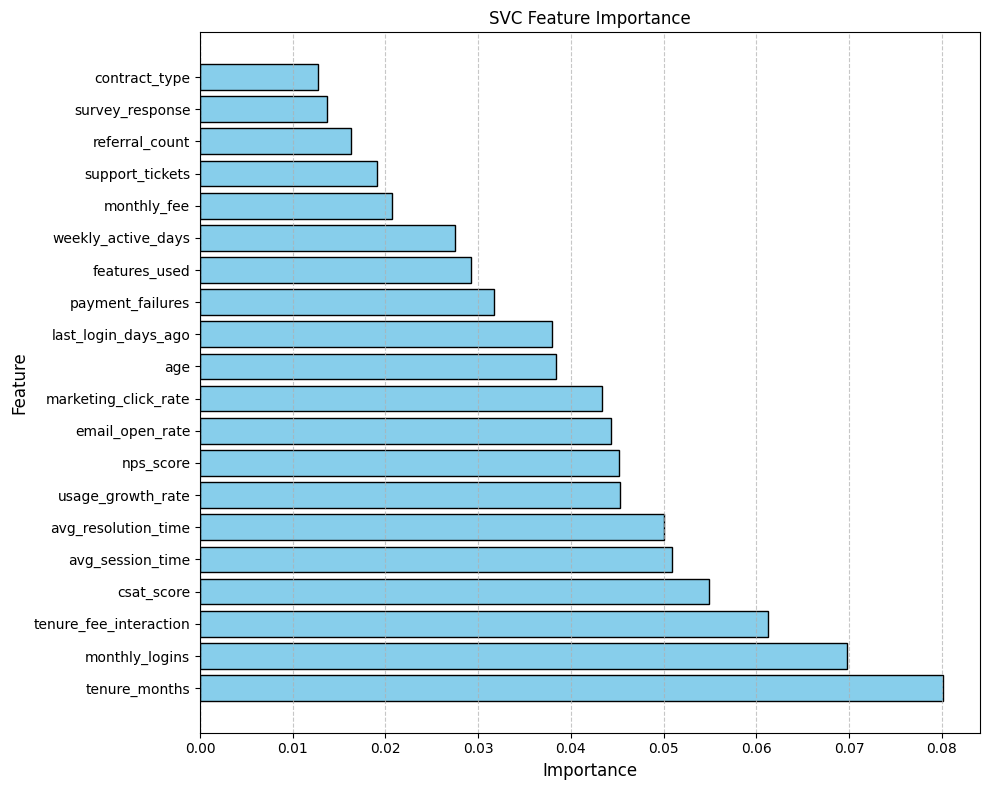

In [167]:
# Plot the important features and importance_means
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in S5_feature_importance_df['importance']]
plt.barh(S5_feature_importance_df['feature'], S5_feature_importance_df['importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('SVC Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Model Summary**     
A dataframe is plotted to summarize the AUC, accuracy, precision, recall, F2 score and profit/loss for the different SVC models.     

The ultimate choice of the predictive model would need to consider the actual relative cost of missing a churner (false negatives - predicted not to churn but churned) and false alarms (false positives - predicted to churn but stayed) in order to determine the optimum mix of precision and recall.   

In [168]:
# Build a comparison dataframe
svc_models_df = pd.DataFrame({
    'SVC': ['Model S3','Model S4','Model S5'],
    'AUC': [auc_S3, auc_S4, auc_S5],
    'Accuracy': [accuracy_S3, accuracy_S4, accuracy_S5],
    'Precision': [precision_S3, precision_S4, precision_S5],
    'Recall': [recall_S3, recall_S4, recall_S5],
    'F2 Score': [F2_score_S3, F2_score_S4, F2_score_S5],
    'Profit/Loss': [Profit_Loss_S3, Profit_Loss_S4, Profit_Loss_S5],
})
svc_models_df

,SVC,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
0,Model S3,0.766,0.442065,0.139079,0.953020,0.439085,26660
1,Model S4,0.779,0.432620,0.134951,0.932886,0.427429,23300
2,Model S5,0.782,0.475441,0.145228,0.939597,0.448718,26940


In [169]:
# Provide an interactive Plotly plot
fig = go.Figure()

#Primary y-axis
metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F2 Score']

for metric in metrics:
    fig.add_trace(
        go.Scatter(
          x=svc_models_df['SVC'],
          y=svc_models_df[metric],
          mode='lines+markers',
          name=metric,
          yaxis='y1'
        )
    )

# Secondary y-axis
fig.add_trace(
        go.Bar(
          x=svc_models_df['SVC'],
          y=svc_models_df['Profit/Loss'],
          name='Profit/Loss',
          yaxis='y2',
          opacity=0.35
       )
)
# Layout
fig.update_layout(
        title='Model Performance and Profit/Loss',
        xaxis=dict(title='SVC'),
        yaxis=dict(
            title='Score',
            range=[0, 1]
        ),
        yaxis2=dict(
            title='Profit/Loss ($)',
            overlaying='y',
            side='right'
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        template='plotly_white',
        hovermode='x unified'
)
fig.show()

In [170]:
# Output the best Decision Tree model performance metrics based on profit/loss
svc_metrics_df = svc_models_df.loc[[svc_models_df["Profit/Loss"].idxmax()]]

svc_metrics_df.to_csv("svc_metrics.csv", index=False)

svc_metrics_df.head()

,SVC,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
2,Model S5,0.782,0.475441,0.145228,0.939597,0.448718,26940


In [171]:
# Output the first eight (8) features importance
model = svc_metrics_df.iloc[0, 0]

if model == 'Model S3':
  print(S3_feature_importance_df.head(8), '\n')
  S3_feature_importance_df.to_csv("svc_features.csv", index=False)
elif model == 'Model S4':
  print(S4_feature_importance_df.head(8), '\n')
  S4_feature_importance_df.to_csv("svc_features.csv", index=False)
else:
  print(S5_feature_importance_df.head(8), '\n')
  S5_feature_importance_df.to_csv("svc_features.csv", index=False)

print(f'The best model is {model}.')

                     feature  importance
Rank                                    
1              tenure_months    0.080117
2             monthly_logins    0.069787
3     tenure_fee_interaction    0.061215
4                 csat_score    0.054914
5           avg_session_time    0.050868
6        avg_resolution_time    0.050043
7          usage_growth_rate    0.045341
8                  nps_score    0.045185 

The best model is Model S5.


**Sample Predictions**

In [172]:
# Establish best model
model = svc_metrics_df.iloc[0, 0]

if model == 'Model S3':
  model_opt = grid_svc_S2_opt
  best_threshold = threshold_S3
elif model == 'Model S4':
  model_opt = grid_svc_S4_opt
  best_threshold = threshold_S4
else:
  model_opt = grid_svc_S5_opt
  best_threshold = threshold_S5

print(f'The best model is {model} and the best threshold is {best_threshold}.')

The best model is Model S5 and the best threshold is 0.05.


**Sample 1**     


In [173]:
# Obtain a sample from the test data
df_test1 = X_test[264:265]

print(df_test1.head().T, '\n')
print(f'Actual churn is {list(y_test[264:265])[0]}') # verify churn

                                 1862
gender                         Female
age                                62
country                        Canada
city                           Sydney
customer_segment           Individual
tenure_months                      18
signup_channel               Referral
contract_type                 Monthly
monthly_logins                     19
weekly_active_days                  1
avg_session_time            23.353293
features_used                       5
usage_growth_rate               -0.01
last_login_days_ago                 5
monthly_fee                        50
payment_method          Bank Transfer
payment_failures                    2
discount_applied                   No
price_increase_last_3m             No
support_tickets                     2
avg_resolution_time         24.419612
complaint_type                Billing
csat_score                        3.0
escalations                         0
email_open_rate                  0.33
marketing_cl

In [174]:
# Transfer the data to a dictionary
sample1 = {
    "gender": "Female",
    "age": 62,
    "country": "Canada",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 18,
    "signup_channel": "Referral",
    "contract_type": "Monthly",
    "monthly_logins": 19,
    "weekly_active_days": 1,
    "avg_session_time": 23.353293,
    "features_used": 5,
    "usage_growth_rate": -0.01,
    "last_login_days_ago": 5,
    "monthly_fee": 50,
    "payment_method": "Bank Transfer",
    "payment_failures": 2,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 2,
    "avg_resolution_time": 24.419612,
    "complaint_type": "Billing",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.33,
    "marketing_click_rate": 0.49,
    "nps_score": -15,
    "survey_response": "Satisfied",
    "referral_count": 1,
    "tenure_fee_interaction": 900
}

In [175]:
# Calculate churn probability of the sample and provide churn of the sample
probability1 = model_opt.predict_proba(pd.DataFrame([sample1]))[:, 1][0]

if probability1 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability1:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.11


**Sample 2**     


In [176]:
# Obtain a sample from the test data
df_test2 = X_test[399:400]

print(df_test2.head().T, '\n')
print(f'The actual churn is {list(y_test[399:400])[0]}') # verify churn

                             1495
gender                       Male
age                            33
country                     India
city                     New York
customer_segment              SME
tenure_months                  40
signup_channel             Mobile
contract_type           Quarterly
monthly_logins                 10
weekly_active_days              2
avg_session_time        20.705153
features_used                   4
usage_growth_rate           -0.33
last_login_days_ago             0
monthly_fee                    50
payment_method               Card
payment_failures                0
discount_applied               No
price_increase_last_3m         No
support_tickets                 0
avg_resolution_time     31.927794
complaint_type          Technical
csat_score                    3.0
escalations                     0
email_open_rate              0.17
marketing_click_rate         0.15
nps_score                      70
survey_response           Neutral
referral_count

In [177]:
# Transfer the data to a dictionary
sample2 = {
    "gender": "Male",
    "age": 33,
    "country": "India",
    "city": "New York",
    "customer_segment": "SME",
    "tenure_months": 40,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 10,
    "weekly_active_days": 2,
    "avg_session_time": 20.705153,
    "features_used": 4,
    "usage_growth_rate": -0.33,
    "last_login_days_ago": 0,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 31.927794,
    "complaint_type": "Technical",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.17,
    "marketing_click_rate": 0.15,
    "nps_score": 70,
    "survey_response": "Neutral",
    "referral_count": 2,
    "tenure_fee_interaction": 2000
}

In [178]:
# Calculate churn probability of the sample and provide churn of the sample
probability2 = model_opt.predict_proba(pd.DataFrame([sample2]))[:, 1]

if probability2 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability2[0]:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.07


**Sample 3**    


In [179]:
# Obtain a sample from the test data
df_test3 = X_test[999:1000]

print(df_test3.head().T, '\n')
print(f'The actual churn is {list(y_test[999:1000])[0]}') # verify churn

                              5713
gender                      Female
age                             51
country                      India
city                         Dhaka
customer_segment        Individual
tenure_months                   12
signup_channel              Mobile
contract_type            Quarterly
monthly_logins                  12
weekly_active_days               7
avg_session_time         10.737885
features_used                    7
usage_growth_rate            -0.11
last_login_days_ago              4
monthly_fee                     50
payment_method                Card
payment_failures                 0
discount_applied               Yes
price_increase_last_3m          No
support_tickets                  3
avg_resolution_time      23.828534
complaint_type             Billing
csat_score                     4.0
escalations                      0
email_open_rate               0.18
marketing_click_rate          0.48
nps_score                       40
survey_response     

In [180]:
# Place the sample data in a dictionary
sample3 = {
    "gender": "Female",
    "age": 51,
    "country": "India",
    "city": "Dhaka",
    "customer_segment": "Individual",
    "tenure_months": 12,
    "signup_channel": "Mobile",
    "contract_type": "Quarterly",
    "monthly_logins": 12,
    "weekly_active_days": 7,
    "avg_session_time": 10.737885,
    "features_used": 7,
    "usage_growth_rate": -0.11,
    "last_login_days_ago": 4,
    "monthly_fee": 50,
    "payment_method": "Card",
    "payment_failures": 0,
    "discount_applied": "Yes",
    "price_increase_last_3m": "No",
    "support_tickets": 3,
    "avg_resolution_time": 23.828534,
    "complaint_type": "Billing",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.18,
    "marketing_click_rate": 0.48,
    "nps_score": 40,
    "survey_response": "Satisfied",
    "referral_count": 2,
    "tenure_fee_interaction": 600
}

In [181]:
# Calculate churn probability of the sample and provide churn of the sample
probability3 = model_opt.predict_proba(pd.DataFrame([sample3]))[:, 1]

if probability3 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability3[0]:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.11


**Sample 4**     


In [182]:
# Obtain another sample from the test data
df_test4 = X_test[125:126]

print(df_test4.head().T, '\n')
print(f'The actual churn is {list(y_test[125:126])[0]}') # verify churn

                                 5786
gender                         Female
age                                51
country                    Bangladesh
city                           London
customer_segment           Individual
tenure_months                      58
signup_channel               Referral
contract_type               Quarterly
monthly_logins                      0
weekly_active_days                  3
avg_session_time            14.899728
features_used                       5
usage_growth_rate                0.11
last_login_days_ago                14
monthly_fee                        20
payment_method          Bank Transfer
payment_failures                    0
discount_applied                   No
price_increase_last_3m             No
support_tickets                     0
avg_resolution_time         13.387985
complaint_type              Technical
csat_score                        4.0
escalations                         0
email_open_rate                  0.22
marketing_cl

In [183]:
# Place the sample data in a dictionary
sample4 = {
    "gender": "Female",
    "age": 51,
    "country": "Bangladesh",
    "city": "London",
    "customer_segment": "Individual",
    "tenure_months": 58,
    "signup_channel": "Referral",
    "contract_type": "Quarterly",
    "monthly_logins": 0,
    "weekly_active_days": 3,
    "avg_session_time": 14.899728,
    "features_used": 5,
    "usage_growth_rate": 0.11,
    "last_login_days_ago": 14,
    "monthly_fee": 20,
    "payment_method": "Bank Transfer",
    "payment_failures": 0,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 0,
    "avg_resolution_time": 13.387985,
    "complaint_type": "Technical",
    "csat_score": 4.0,
    "escalations": 0,
    "email_open_rate": 0.22,
    "marketing_click_rate": 0.19,
    "nps_score": 50,
    "survey_response": "Satisfied",
    "referral_count": 0,
    "tenure_fee_interaction": 1160
}

In [184]:
# Calculate churn probability of the sample and provide churn of the sample
probability4 = model_opt.predict_proba(pd.DataFrame([sample4]))[:, 1]

if probability4 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability4[0]:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.06


**Sample 5**    


In [185]:
# Obtain another sample from the test data
df_test5 = X_test[1125:1126]

print(df_test5.head().T, '\n')
print(f'The actual churn is {list(y_test[1125:1126])[0]}') # verify churn

                              6970
gender                      Female
age                             38
country                         UK
city                        Sydney
customer_segment        Individual
tenure_months                   14
signup_channel                 Web
contract_type              Monthly
monthly_logins                  10
weekly_active_days               3
avg_session_time         10.354267
features_used                    5
usage_growth_rate            -0.14
last_login_days_ago              3
monthly_fee                     50
payment_method                Card
payment_failures                 1
discount_applied                No
price_increase_last_3m          No
support_tickets                  1
avg_resolution_time       9.362325
complaint_type             Service
csat_score                     3.0
escalations                      0
email_open_rate               0.56
marketing_click_rate          0.49
nps_score                       87
survey_response     

In [186]:
# Place the sample data in a dictionary
sample5 = {
    "gender": "Female",
    "age": 38,
    "country": "UK",
    "city": "Sydney",
    "customer_segment": "Individual",
    "tenure_months": 14,
    "signup_channel": "Web",
    "contract_type": "Monthly",
    "monthly_logins": 10,
    "weekly_active_days": 3,
    "avg_session_time": 10.354267,
    "features_used": 5,
    "usage_growth_rate": -0.14,
    "last_login_days_ago": 3,
    "monthly_fee": 50,
    "total_revenue": 700,
    "payment_method": "Card",
    "payment_failures": 1,
    "discount_applied": "No",
    "price_increase_last_3m": "No",
    "support_tickets": 1,
    "avg_resolution_time": 9.362325,
    "complaint_type": "Service",
    "csat_score": 3.0,
    "escalations": 0,
    "email_open_rate": 0.56,
    "marketing_click_rate": 0.49,
    "nps_score": 87,
    "survey_response": "Neutral",
    "referral_count": 0,
    "tenure_fee_interaction": 700
}

In [187]:
# Calculate churn probability of the sample and provide churn of the sample
probability5 = model_opt.predict_proba(pd.DataFrame([sample5]))[:, 1]

if probability5 >= best_threshold:
    print(f'The predicted churn is 1 \n')
else:
    print(f'The predicted churn is 0 \n')

print(f'The predicted churn probability is {probability5[0]:.2f}')

The predicted churn is 1 

The predicted churn probability is 0.16
